In [1]:
!pip install torchmetrics datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 30.8 MB/s eta 0:00:00


In [2]:
import torch
import torchmetrics
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset


from sklearn.model_selection import train_test_split

import datasets
from datasets import load_dataset

import re
import pandas as pd
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt

# Data Handling

In [3]:
dataset = load_dataset("codesignal/sms-spam-collection")
df = pd.DataFrame(dataset["train"])

df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sms-spam-collection.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/5572 [00:00<?, ? examples/s]

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
# Encode labels
df["label"] = df["label"].map({"ham": 0, "spam": 1})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
# Split data into train, val, test
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df["label"], random_state=42
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42
)

print(len(train_df), len(val_df), len(test_df))

3900 836 836


## Tokenization Strategy

In [6]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    tokens = text.split()
    return tokens

## Vocabulary Building

In [7]:
max_vocab_size = 5000

counter = Counter()

for text in train_df["message"]:
    tokens = tokenize(text)
    counter.update(tokens)

most_common = counter.most_common(max_vocab_size - 2)

vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

for i, (word, _) in enumerate(most_common, start=2):
    vocab[word] = i

vocab_size = len(vocab)

print("Vocab Size: ", vocab_size)

Vocab Size:  5000


## Text to Sequence Encoding

In [8]:
def encode(tokens, vocab):
    return [vocab.get(token, vocab["<UNK>"]) for token in tokens]

## Padding Function

In [9]:
max_length = 40

def pad_sequence(seq, max_length):
    if len(seq) < max_length:
        seq = seq + [0] * (max_length - len(seq))
    else:
        seq = seq[:max_length]
    
    return seq

# Dataset Class

In [10]:
class SpamDataset(Dataset):
    def __init__(self, dataframe, vocab, max_length):
        self.texts = dataframe["message"].tolist()
        self.labels = dataframe["label"].tolist()
        self.vocab = vocab
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, index):
        text = self.texts[index]
        label = self.labels[index]

        tokens = tokenize(text)
        encoded = encode(tokens, self.vocab)
        padded = pad_sequence(encoded, self.max_length)

        return (
            torch.tensor(padded, dtype=torch.long),
            torch.tensor(label, dtype=torch.float)
        )

# Helper Functions

In [11]:
def get_loaders(train_df, val_df, test_df, vocab, max_length=40, batch_size=32):
    
    train_dataset = SpamDataset(train_df, vocab, max_length)
    val_dataset = SpamDataset(val_df, vocab, max_length)
    test_dataset = SpamDataset(test_df, vocab, max_length)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [12]:
def training_setup(model):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    return criterion, optimizer

In [13]:
def get_metrics(device):

    metrics = torchmetrics.MetricCollection({
        "accuracy": torchmetrics.classification.BinaryAccuracy(),
        "precision": torchmetrics.classification.BinaryPrecision(),
        "recall": torchmetrics.classification.BinaryRecall(),
        "f1": torchmetrics.classification.BinaryF1Score(),
        "conf_mat": torchmetrics.classification.BinaryConfusionMatrix()
    }).to(device)

    return metrics

In [14]:
def train(model, dataloader, criterion, optimizer, metrics, device):
    model.train()
    metrics.reset()
    epoch_loss = 0.0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        preds = torch.sigmoid(outputs)

        metrics.update(preds, labels.int())
    
    epoch_loss /= len(dataloader)

    return epoch_loss

In [15]:
def validate(model, dataloader, criterion, metrics, device):
    model.eval()
    metrics.reset()
    epoch_loss = 0.0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            epoch_loss += loss.item()

            preds = torch.sigmoid(outputs)

            metrics.update(preds, labels.int())
    
    epoch_loss /= len(dataloader)
    
    return epoch_loss

In [16]:
def plot_learning_curves(train_losses, val_losses, train_accs, val_accs):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-', label='Training Loss')
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, 'b-', label='Training Acc')
    plt.plot(epochs, val_accs, 'r-', label='Validation Acc')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Reusable Components

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [18]:
train_loader, val_loader, test_loader = get_loaders(train_df, val_df, test_df, vocab)

In [19]:
train_metrics = get_metrics(device)
val_metrics = get_metrics(device)
test_metrics = get_metrics(device)

In [20]:
EPOCHS = 50

# LSTM Classfier

In [21]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=128):
        super(LSTMClassifier, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)

        self.fc = nn.Linear(hidden_dim, 1)
    
    def forward(self, x):
        embedded = self.embedding(x)

        output, (hidden, cell) = self.lstm(embedded)

        final_hidden = hidden[-1]

        logits = self.fc(final_hidden)

        return logits.squeeze(1)

## Training

In [22]:
lstm_model = LSTMClassifier(vocab_size).to(device)
criterion, optimizer = training_setup(lstm_model)

In [23]:
train_history = {"train_loss":[], "train_acc":[]}
val_history = {"val_loss":[], "val_acc":[]}

In [24]:
print("LSTM Classifier Started Training...\n")
for epoch in range(EPOCHS):
    train_loss = train(lstm_model, train_loader, criterion, optimizer, train_metrics, device)
    val_loss = validate(lstm_model, val_loader, criterion, val_metrics, device)

    train_results = train_metrics.compute()
    val_results = val_metrics.compute()

    train_history["train_loss"].append(train_loss)
    train_history["train_acc"].append(train_results["accuracy"].item())

    val_history["val_loss"].append(val_loss)
    val_history["val_acc"].append(val_results["accuracy"].item())

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_results['accuracy']:.4f} | "
        f"Val Acc: {val_results['accuracy']:.4f}"
    )

print("\nLSTM Classifier Training Complete!")

LSTM Classifier Started Training...

Epoch 1/50 | Train Loss: 0.2992 | Val Loss: 0.1602 | Train Acc: 0.8818 | Val Acc: 0.9593
Epoch 2/50 | Train Loss: 0.1503 | Val Loss: 0.1101 | Train Acc: 0.9474 | Val Acc: 0.9617
Epoch 3/50 | Train Loss: 0.0885 | Val Loss: 0.1055 | Train Acc: 0.9746 | Val Acc: 0.9689
Epoch 4/50 | Train Loss: 0.0729 | Val Loss: 0.0905 | Train Acc: 0.9813 | Val Acc: 0.9749
Epoch 5/50 | Train Loss: 0.0675 | Val Loss: 0.1368 | Train Acc: 0.9826 | Val Acc: 0.9617
Epoch 6/50 | Train Loss: 0.0786 | Val Loss: 0.1147 | Train Acc: 0.9779 | Val Acc: 0.9701
Epoch 7/50 | Train Loss: 0.0703 | Val Loss: 0.0941 | Train Acc: 0.9826 | Val Acc: 0.9785
Epoch 8/50 | Train Loss: 0.0556 | Val Loss: 0.1355 | Train Acc: 0.9851 | Val Acc: 0.9641
Epoch 9/50 | Train Loss: 0.0706 | Val Loss: 0.0944 | Train Acc: 0.9797 | Val Acc: 0.9737
Epoch 10/50 | Train Loss: 0.1300 | Val Loss: 0.1487 | Train Acc: 0.9669 | Val Acc: 0.9593
Epoch 11/50 | Train Loss: 0.0635 | Val Loss: 0.0977 | Train Acc: 0.9828 

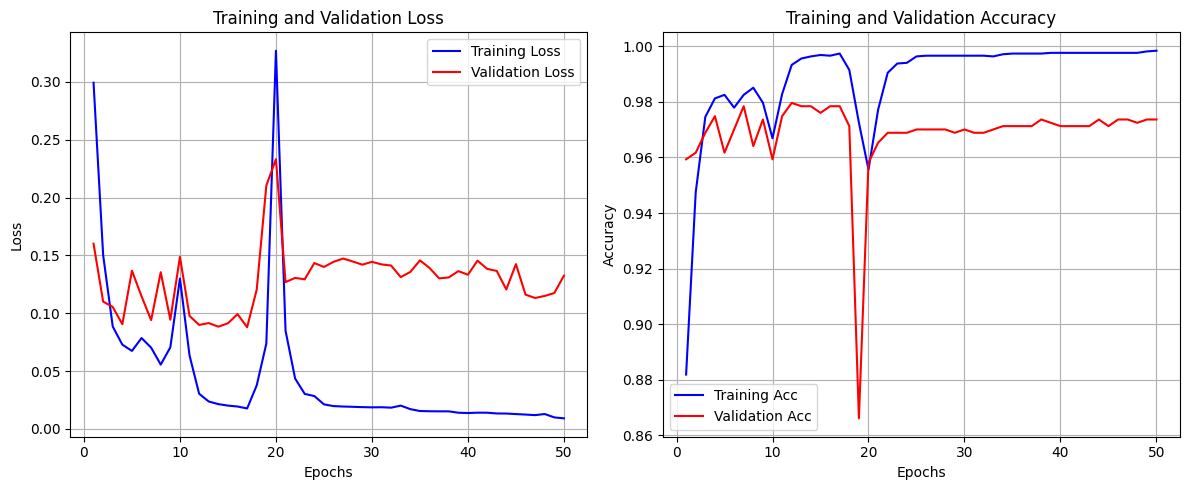

In [25]:
plot_learning_curves(train_history["train_loss"], val_history["val_loss"], train_history["train_acc"], val_history["val_acc"])

In [26]:
final_val_metrics = val_metrics.compute()

print("---Final Validation Metrics---")
print("Accuracy: ", final_val_metrics["accuracy"].item())
print("Precision: ", final_val_metrics["precision"].item())
print("Recall: ", final_val_metrics["recall"].item())
print("F1 Score: ", final_val_metrics["f1"].item())

---Final Validation Metrics---
Accuracy:  0.9736841917037964
Precision:  0.9090909361839294
Recall:  0.8928571343421936
F1 Score:  0.9009009003639221


## Evaluation

In [27]:
test_loss = validate(lstm_model, test_loader, criterion, test_metrics, device)
test_results = test_metrics.compute()

print("---Test Results---")
print("Accuracy: ", test_results["accuracy"].item())
print("Precision: ", test_results["precision"].item())
print("Recall: ", test_results["recall"].item())
print("F1 Score: ", test_results["f1"].item())

---Test Results---
Accuracy:  0.9772727489471436
Precision:  0.9345794320106506
Recall:  0.8928571343421936
F1 Score:  0.913241982460022


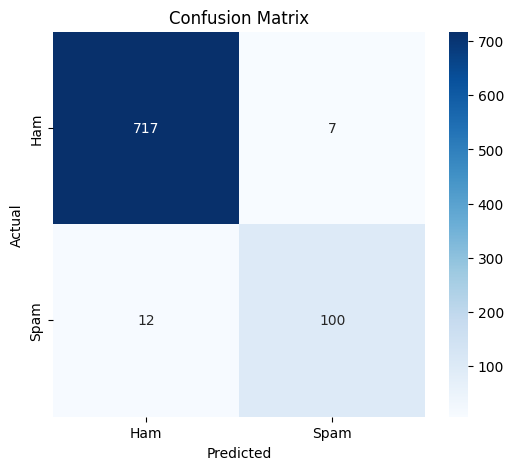

In [28]:
conf_mat = test_results["conf_mat"].cpu().numpy()

plt.figure(figsize=(6,5))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham","Spam"],
            yticklabels=["Ham","Spam"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# RNN Classifier

In [29]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=128):
        super(RNNClassifier, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, 1)
    
    def forward(self, x):
        embedded = self.embedding(x)

        output, hidden = self.rnn(embedded)

        final_hidden = hidden[-1]

        logits = self.fc(final_hidden)

        return logits.squeeze(1)

## Training

In [30]:
rnn_model = RNNClassifier(vocab_size).to(device)
criterion, optimizer = training_setup(rnn_model)

In [31]:
train_history = {"train_loss":[], "train_acc":[]}
val_history = {"val_loss":[], "val_acc":[]}

In [32]:
print("RNN Classifier Started Training...\n")
for epoch in range(EPOCHS):
    train_loss = train(rnn_model, train_loader, criterion, optimizer, train_metrics, device)
    val_loss = validate(rnn_model, val_loader, criterion, val_metrics, device)

    train_results = train_metrics.compute()
    val_results = val_metrics.compute()

    train_history["train_loss"].append(train_loss)
    train_history["train_acc"].append(train_results["accuracy"].item())

    val_history["val_loss"].append(val_loss)
    val_history["val_acc"].append(val_results["accuracy"].item())

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_results['accuracy']:.4f} | "
        f"Val Acc: {val_results['accuracy']:.4f}"
    )

print("\nLSTM Classifier Training Complete!")

RNN Classifier Started Training...

Epoch 1/50 | Train Loss: 0.4103 | Val Loss: 0.4038 | Train Acc: 0.8605 | Val Acc: 0.8660
Epoch 2/50 | Train Loss: 0.3956 | Val Loss: 0.4016 | Train Acc: 0.8659 | Val Acc: 0.8660
Epoch 3/50 | Train Loss: 0.3955 | Val Loss: 0.4031 | Train Acc: 0.8662 | Val Acc: 0.8660
Epoch 4/50 | Train Loss: 0.3971 | Val Loss: 0.4076 | Train Acc: 0.8654 | Val Acc: 0.8660
Epoch 5/50 | Train Loss: 0.3952 | Val Loss: 0.4038 | Train Acc: 0.8654 | Val Acc: 0.8648
Epoch 6/50 | Train Loss: 0.4009 | Val Loss: 0.4065 | Train Acc: 0.8618 | Val Acc: 0.8672
Epoch 7/50 | Train Loss: 0.3915 | Val Loss: 0.4056 | Train Acc: 0.8487 | Val Acc: 0.8660
Epoch 8/50 | Train Loss: 0.3809 | Val Loss: 0.4046 | Train Acc: 0.8672 | Val Acc: 0.8660
Epoch 9/50 | Train Loss: 0.3917 | Val Loss: 0.4053 | Train Acc: 0.8659 | Val Acc: 0.8660
Epoch 10/50 | Train Loss: 0.3895 | Val Loss: 0.4010 | Train Acc: 0.8659 | Val Acc: 0.8648
Epoch 11/50 | Train Loss: 0.3905 | Val Loss: 0.4023 | Train Acc: 0.8659 |

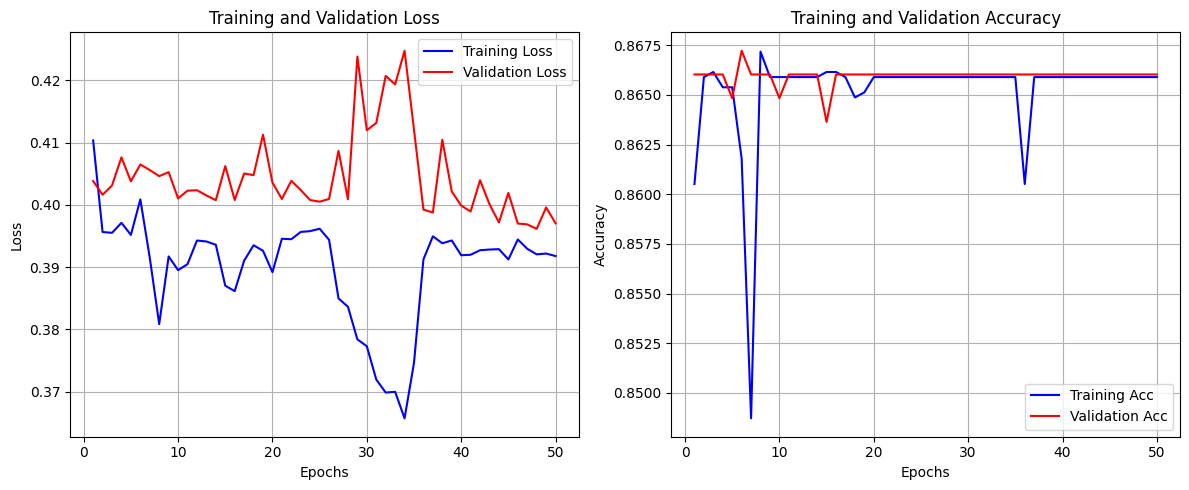

In [33]:
plot_learning_curves(train_history["train_loss"], val_history["val_loss"], train_history["train_acc"], val_history["val_acc"])

In [34]:
final_val_metrics = val_metrics.compute()

print("---Final Validation Metrics---")
print("Accuracy: ", final_val_metrics["accuracy"].item())
print("Precision: ", final_val_metrics["precision"].item())
print("Recall: ", final_val_metrics["recall"].item())
print("F1 Score: ", final_val_metrics["f1"].item())

---Final Validation Metrics---
Accuracy:  0.8660287261009216
Precision:  0.0
Recall:  0.0
F1 Score:  0.0


## Evaluation

In [35]:
test_loss = validate(rnn_model, test_loader, criterion, test_metrics, device)
test_results = test_metrics.compute()

print("---Test Results---")
print("Accuracy: ", test_results["accuracy"].item())
print("Precision: ", test_results["precision"].item())
print("Recall: ", test_results["recall"].item())
print("F1 Score: ", test_results["f1"].item())

---Test Results---
Accuracy:  0.8660287261009216
Precision:  0.0
Recall:  0.0
F1 Score:  0.0


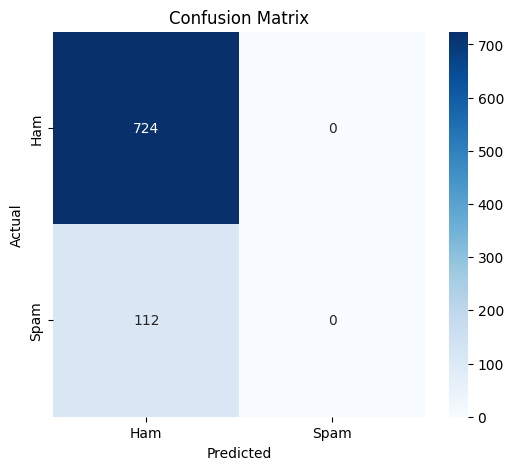

In [36]:
conf_mat = test_results["conf_mat"].cpu().numpy()

plt.figure(figsize=(6,5))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham","Spam"],
            yticklabels=["Ham","Spam"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# GRU Classifier

In [ ]:
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=128):
        super(GRUClassifier, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, 1)
    
    def forward(self, x):
        embedded = self.embedding(x)

        output, hidden = self.rnn(embedded)

        final_hidden = hidden[-1]

        logits = self.fc(final_hidden)

        return logits.squeeze(1)

## Training

In [ ]:
gru_model = GRUClassifier(vocab_size).to(device)
criterion, optimizer = training_setup(gru_model)

In [ ]:
train_history = {"train_loss":[], "train_acc":[]}
val_history = {"val_loss":[], "val_acc":[]}

In [ ]:
print("GRU Classifier Started Training...\n")
for epoch in range(EPOCHS):
    train_loss = train(gru_model, train_loader, criterion, optimizer, train_metrics, device)
    val_loss = validate(gru_model, val_loader, criterion, val_metrics, device)

    train_results = train_metrics.compute()
    val_results = val_metrics.compute()

    train_history["train_loss"].append(train_loss)
    train_history["train_acc"].append(train_results["accuracy"].item())

    val_history["val_loss"].append(val_loss)
    val_history["val_acc"].append(val_results["accuracy"].item())

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_results['accuracy']:.4f} | "
        f"Val Acc: {val_results['accuracy']:.4f}"
    )

print("\nLSTM Classifier Training Complete!")

In [ ]:
plot_learning_curves(train_history["train_loss"], val_history["val_loss"], train_history["train_acc"], val_history["val_acc"])

In [ ]:
final_val_metrics = val_metrics.compute()

print("---Final Validation Metrics---")
print("Accuracy: ", final_val_metrics["accuracy"].item())
print("Precision: ", final_val_metrics["precision"].item())
print("Recall: ", final_val_metrics["recall"].item())
print("F1 Score: ", final_val_metrics["f1"].item())

## Evaluation

In [ ]:
test_loss = validate(gru_model, test_loader, criterion, test_metrics, device)
test_results = test_metrics.compute()

print("---Test Results---")
print("Accuracy: ", test_results["accuracy"].item())
print("Precision: ", test_results["precision"].item())
print("Recall: ", test_results["recall"].item())
print("F1 Score: ", test_results["f1"].item())

In [ ]:
conf_mat = test_results["conf_mat"].cpu().numpy()

plt.figure(figsize=(6,5))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham","Spam"],
            yticklabels=["Ham","Spam"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()